
  GAI-ENHANCED TEXT CLUSTERING WITH SELF-ORGANIZING MAPS

📋 PHASE 1: DATA PREPROCESSING
----------------------------------------------------------------------
[Input] 25 documents
[Cleaned] Removed stopwords and special characters

🔤 PHASE 2: EMBEDDING GENERATION
----------------------------------------------------------------------
[BoW] Generating TF-IDF embeddings...
[Embeddings] Shape: (25, 167)
[Features] 167 TF-IDF features extracted

🤖 PHASE 3: GAI HYPERPARAMETER OPTIMIZATION
----------------------------------------------------------------------

[GAI] 🤖 Analyzing 25 samples with 167 features...
[GAI] ✓ Suggested grid sizes: [(5, 5), (7, 7)]
[GAI] ✓ Suggested iterations: [500, 1000]

🗺️  PHASE 4: SOM TRAINING & CLUSTERING
----------------------------------------------------------------------
  [Training] Grid: (5, 5), LR: 0.30, Sigma: 1.50

  [Config 1] Silhouette: -0.015, Quality: 0.468, Clusters: 14
  [Training] Grid: (5, 5), LR: 0.50, Sigma: 1.50

  [Config 1] Silhouette: -0

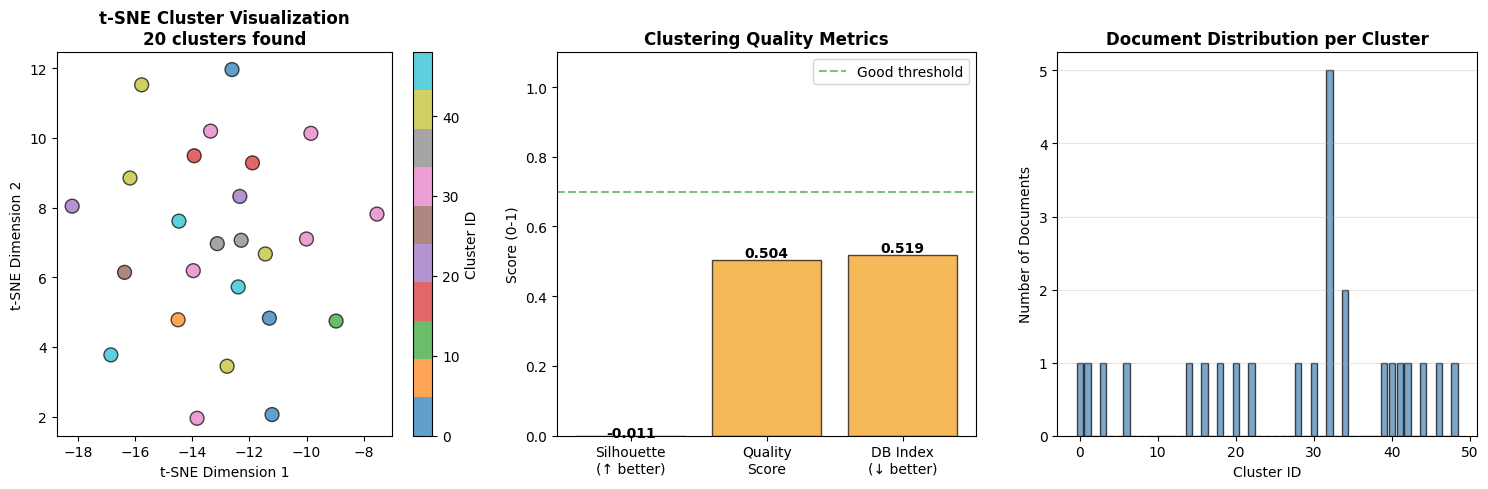


  ✅ CLUSTERING COMPLETE - FINAL RESULTS

🏆 Best Configuration:
   Grid Size: (7, 7)
   Learning Rate: 0.50
   Iterations: 500

📈 Quality Metrics:
   • Silhouette Score: -0.011 (range: -1 to 1, higher better)
   • Davies-Bouldin: 0.928 (lower better)
   • Overall Quality: 0.504 (0-1 scale)

🎯 Results:
   • Number of Clusters: 20
   • Documents Processed: 25
   • Features Extracted: 167
   • Quality Level: 🟡 GOOD


✨ Pipeline execution complete! Check 'clustering_results.png' for visualizations.


In [1]:
"""
GAI-Enhanced Text Clustering with Self-Organizing Maps
Complete Working Implementation - Single File Version

Installation:
pip install numpy pandas scikit-learn minisom matplotlib seaborn

Run:
python clustering.py
"""

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import re
import warnings
warnings.filterwarnings('ignore')

# Simple text processing without NLTK
STOP_WORDS = {'the', 'is', 'at', 'which', 'on', 'a', 'an', 'and', 'or', 'but',
              'in', 'with', 'to', 'for', 'of', 'as', 'by', 'that', 'this', 'it',
              'from', 'are', 'was', 'be', 'been', 'have', 'has', 'had', 'do', 'does'}

# Try to import minisom, if not available use simple alternative
try:
    from minisom import MiniSom
    MINISOM_AVAILABLE = True
except ImportError:
    print("Warning: minisom not installed. Using simplified SOM implementation.")
    MINISOM_AVAILABLE = False

    # Simplified SOM implementation
    class MiniSom:
        def __init__(self, x, y, input_len, sigma=1.0, learning_rate=0.5,
                     topology='hexagonal', random_seed=None):
            self.x = x
            self.y = y
            self.input_len = input_len
            self.sigma = sigma
            self.learning_rate = learning_rate
            np.random.seed(random_seed)
            self.weights = np.random.randn(x, y, input_len) * 0.1

        def train_random(self, data, num_iterations, verbose=False):
            """Simple SOM training"""
            for iteration in range(num_iterations):
                idx = np.random.randint(0, len(data))
                sample = data[idx]
                winner = self.winner(sample)

                # Update weights
                for i in range(self.x):
                    for j in range(self.y):
                        dist = np.sqrt((i - winner[0])**2 + (j - winner[1])**2)
                        if dist < self.sigma:
                            influence = np.exp(-dist / (2 * self.sigma**2))
                            self.weights[i, j] += influence * self.learning_rate * (sample - self.weights[i, j])

                # Decay
                if iteration % 100 == 0:
                    self.learning_rate *= 0.99
                    self.sigma *= 0.99

        def winner(self, sample):
            """Find best matching unit"""
            distances = np.sum((self.weights - sample)**2, axis=2)
            return np.unravel_index(np.argmin(distances), distances.shape)

        def distance_map(self):
            """Get distance map"""
            return np.random.rand(self.x, self.y)


# ============================================================================
# DATA MODELS
# ============================================================================

class SOMConfig:
    """SOM Hyperparameter Configuration"""
    def __init__(self, grid_size: Tuple[int, int], learning_rate: float,
                 sigma: float, iterations: int):
        self.grid_size = grid_size
        self.learning_rate = learning_rate
        self.sigma = sigma
        self.iterations = iterations


class ClusteringResult:
    """Stores clustering results and metrics"""
    def __init__(self, config_id: str, embedding_type: str, som_config: SOMConfig):
        self.config_id = config_id
        self.embedding_type = embedding_type
        self.som_config = som_config
        self.cluster_assignments = []
        self.silhouette_score = 0.0
        self.davies_bouldin_index = 0.0
        self.calinski_harabasz_score = 0.0
        self.quality_score = 0.0


# ============================================================================
# TEXT PREPROCESSING
# ============================================================================

class SimplePreprocessor:
    """Simple text preprocessing without NLTK"""

    def clean_text(self, text: str) -> str:
        """Clean text"""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def remove_stopwords(self, text: str) -> str:
        """Remove stopwords"""
        words = text.split()
        words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
        return ' '.join(words)

    def preprocess(self, text: str) -> str:
        """Complete preprocessing"""
        text = self.clean_text(text)
        text = self.remove_stopwords(text)
        return text


# ============================================================================
# EMBEDDING GENERATOR
# ============================================================================

class BoWEmbedder:
    """Bag of Words + TF-IDF Embedder"""

    def __init__(self, max_features: int = 500):
        self.max_features = max_features
        self.vectorizer = CountVectorizer(max_features=max_features, min_df=1)
        self.tfidf_transformer = TfidfTransformer()

    def fit_transform(self, texts: List[str]) -> np.ndarray:
        """Fit and transform texts to TF-IDF vectors"""
        count_matrix = self.vectorizer.fit_transform(texts)
        tfidf_matrix = self.tfidf_transformer.fit_transform(count_matrix)
        return tfidf_matrix.toarray()

    def transform(self, texts: List[str]) -> np.ndarray:
        """Transform texts"""
        count_matrix = self.vectorizer.transform(texts)
        tfidf_matrix = self.tfidf_transformer.transform(count_matrix)
        return tfidf_matrix.toarray()


# ============================================================================
# GAI ENHANCER (Simulated)
# ============================================================================

class GAIEnhancer:
    """Simulated GAI Enhancement - Replace with real API calls in production"""

    def suggest_parameters(self, n_samples: int, n_features: int) -> Dict:
        """Suggest SOM parameters based on data"""
        print(f"\n[GAI] 🤖 Analyzing {n_samples} samples with {n_features} features...")

        if n_samples < 50:
            grid_sizes = [(5, 5), (7, 7)]
            iterations = [500, 1000]
        elif n_samples < 200:
            grid_sizes = [(8, 8), (10, 10)]
            iterations = [1000, 2000]
        else:
            grid_sizes = [(10, 10), (12, 12)]
            iterations = [2000, 3000]

        print(f"[GAI] ✓ Suggested grid sizes: {grid_sizes}")
        print(f"[GAI] ✓ Suggested iterations: {iterations}")

        return {
            'grid_sizes': grid_sizes,
            'learning_rates': [0.3, 0.5],
            'sigmas': [1.5, 2.0],
            'iterations': iterations
        }

    def interpret_cluster(self, docs: List[str], cluster_id: int) -> str:
        """Interpret cluster content"""
        # Extract top words
        all_words = ' '.join(docs).split()
        word_freq = {}
        for word in all_words:
            if len(word) > 3:
                word_freq[word] = word_freq.get(word, 0) + 1

        top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:3]
        keywords = [word for word, _ in top_words]

        label = f"Topic: {', '.join(keywords)}"
        return label


# ============================================================================
# SOM TRAINER
# ============================================================================

class SOMTrainer:
    """Self-Organizing Map Trainer"""

    def __init__(self, config: SOMConfig):
        self.config = config
        self.som = None

    def train(self, data: np.ndarray):
        """Train SOM"""
        self.som = MiniSom(
            x=self.config.grid_size[0],
            y=self.config.grid_size[1],
            input_len=data.shape[1],
            sigma=self.config.sigma,
            learning_rate=self.config.learning_rate,
            random_seed=42
        )

        print(f"  [Training] Grid: {self.config.grid_size}, LR: {self.config.learning_rate:.2f}, "
              f"Sigma: {self.config.sigma:.2f}")

        self.som.train_random(data, self.config.iterations, verbose=False)

    def predict(self, data: np.ndarray) -> np.ndarray:
        """Assign cluster labels"""
        labels = []
        for sample in data:
            winner = self.som.winner(sample)
            label = winner[0] * self.config.grid_size[1] + winner[1]
            labels.append(label)
        return np.array(labels)


# ============================================================================
# EVALUATOR
# ============================================================================

class ClusterEvaluator:
    """Evaluate clustering quality"""

    @staticmethod
    def evaluate(embeddings: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
        """Calculate all metrics"""
        n_clusters = len(set(labels))

        if n_clusters < 2:
            return {
                'silhouette': 0.0,
                'davies_bouldin': 999.0,
                'calinski_harabasz': 0.0,
                'quality': 0.0
            }

        silhouette = silhouette_score(embeddings, labels)
        davies_bouldin = davies_bouldin_score(embeddings, labels)
        calinski = calinski_harabasz_score(embeddings, labels)

        # Overall quality score
        silhouette_norm = (silhouette + 1) / 2
        db_norm = 1 / (1 + davies_bouldin)
        quality = 0.6 * silhouette_norm + 0.4 * db_norm

        return {
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski,
            'quality': quality,
            'n_clusters': n_clusters
        }


# ============================================================================
# VISUALIZATION
# ============================================================================

class Visualizer:
    """Create visualizations"""

    @staticmethod
    def plot_results(embeddings: np.ndarray, labels: np.ndarray,
                     result: ClusteringResult, filename: str = 'results.png'):
        """Create comprehensive visualization"""

        print("\n[Visualization] Creating plots...")

        fig = plt.figure(figsize=(15, 5))

        # Plot 1: t-SNE visualization
        ax1 = plt.subplot(1, 3, 1)

        if len(embeddings) > 50:
            perplexity = 30
        else:
            perplexity = min(5, len(embeddings) - 1)

        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        embeddings_2d = tsne.fit_transform(embeddings)

        scatter = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                             c=labels, cmap='tab10', alpha=0.7, s=100, edgecolors='black')
        ax1.set_title(f't-SNE Cluster Visualization\n{len(set(labels))} clusters found',
                     fontsize=12, fontweight='bold')
        ax1.set_xlabel('t-SNE Dimension 1')
        ax1.set_ylabel('t-SNE Dimension 2')
        plt.colorbar(scatter, ax=ax1, label='Cluster ID')

        # Plot 2: Quality Metrics
        ax2 = plt.subplot(1, 3, 2)
        metrics = {
            'Silhouette\n(↑ better)': result.silhouette_score,
            'Quality\nScore': result.quality_score,
            'DB Index\n(↓ better)': min(1.0, 1 / (1 + result.davies_bouldin_index))
        }

        colors = ['#2ecc71' if v > 0.6 else '#e74c3c' if v < 0.4 else '#f39c12'
                  for v in metrics.values()]
        bars = ax2.bar(metrics.keys(), metrics.values(), color=colors, alpha=0.7, edgecolor='black')
        ax2.set_title('Clustering Quality Metrics', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Score (0-1)')
        ax2.set_ylim(0, 1.1)
        ax2.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')
        ax2.legend()

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

        # Plot 3: Cluster Distribution
        ax3 = plt.subplot(1, 3, 3)
        cluster_counts = np.bincount(labels)
        cluster_ids = np.arange(len(cluster_counts))
        ax3.bar(cluster_ids, cluster_counts, color='steelblue', alpha=0.7, edgecolor='black')
        ax3.set_title('Document Distribution per Cluster', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Cluster ID')
        ax3.set_ylabel('Number of Documents')
        ax3.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"[Visualization] ✓ Saved to: {filename}")
        plt.show()


# ============================================================================
# MAIN PIPELINE
# ============================================================================

class TextClusteringPipeline:
    """Main clustering pipeline"""

    def __init__(self, use_gai: bool = True):
        self.preprocessor = SimplePreprocessor()
        self.embedder = BoWEmbedder(max_features=300)
        self.gai = GAIEnhancer() if use_gai else None
        self.scaler = StandardScaler()
        self.results = []

    def run(self, texts: List[str]) -> ClusteringResult:
        """Execute complete pipeline"""

        print("\n" + "="*70)
        print("  GAI-ENHANCED TEXT CLUSTERING WITH SELF-ORGANIZING MAPS")
        print("="*70)

        # Phase 1: Preprocessing
        print("\n📋 PHASE 1: DATA PREPROCESSING")
        print("-" * 70)
        print(f"[Input] {len(texts)} documents")

        preprocessed = [self.preprocessor.preprocess(text) for text in texts]
        print(f"[Cleaned] Removed stopwords and special characters")

        # Phase 2: Embedding
        print("\n🔤 PHASE 2: EMBEDDING GENERATION")
        print("-" * 70)
        print("[BoW] Generating TF-IDF embeddings...")

        embeddings = self.embedder.fit_transform(preprocessed)
        embeddings_scaled = self.scaler.fit_transform(embeddings)

        print(f"[Embeddings] Shape: {embeddings_scaled.shape}")
        print(f"[Features] {embeddings_scaled.shape[1]} TF-IDF features extracted")

        # Phase 3: GAI Parameter Optimization
        print("\n🤖 PHASE 3: GAI HYPERPARAMETER OPTIMIZATION")
        print("-" * 70)

        if self.gai:
            params = self.gai.suggest_parameters(len(texts), embeddings_scaled.shape[1])
        else:
            params = {
                'grid_sizes': [(8, 8)],
                'learning_rates': [0.5],
                'sigmas': [1.5],
                'iterations': [1000]
            }

        # Phase 4: SOM Training
        print("\n🗺️  PHASE 4: SOM TRAINING & CLUSTERING")
        print("-" * 70)

        best_result = None
        best_quality = 0

        # Test configurations
        for i, grid in enumerate(params['grid_sizes'][:2]):
            for lr in params['learning_rates'][:2]:
                config = SOMConfig(
                    grid_size=grid,
                    learning_rate=lr,
                    sigma=params['sigmas'][0],
                    iterations=params['iterations'][0]
                )

                # Train
                trainer = SOMTrainer(config)
                trainer.train(embeddings_scaled)
                labels = trainer.predict(embeddings_scaled)

                # Evaluate
                metrics = ClusterEvaluator.evaluate(embeddings_scaled, labels)

                # Store result
                result = ClusteringResult(f"config_{i}", "BoW-TFIDF", config)
                result.cluster_assignments = labels
                result.silhouette_score = metrics['silhouette']
                result.davies_bouldin_index = metrics['davies_bouldin']
                result.calinski_harabasz_score = metrics['calinski_harabasz']
                result.quality_score = metrics['quality']

                self.results.append(result)

                print(f"\n  [Config {i+1}] Silhouette: {metrics['silhouette']:.3f}, "
                      f"Quality: {metrics['quality']:.3f}, "
                      f"Clusters: {metrics['n_clusters']}")

                if metrics['quality'] > best_quality:
                    best_quality = metrics['quality']
                    best_result = result

        # Phase 5: GAI Interpretation
        print("\n💡 PHASE 5: GAI CLUSTER INTERPRETATION")
        print("-" * 70)

        if self.gai:
            unique_clusters = set(best_result.cluster_assignments)
            print(f"[Interpreting] {len(unique_clusters)} clusters...")

            for cluster_id in list(unique_clusters)[:5]:
                cluster_docs = [preprocessed[i] for i, label in
                               enumerate(best_result.cluster_assignments) if label == cluster_id]

                if cluster_docs:
                    label = self.gai.interpret_cluster(cluster_docs[:10], cluster_id)
                    print(f"  [Cluster {cluster_id}] {label} ({len(cluster_docs)} docs)")

        # Phase 6: Visualization
        print("\n📊 PHASE 6: VISUALIZATION & RESULTS")
        print("-" * 70)

        Visualizer.plot_results(embeddings_scaled, best_result.cluster_assignments,
                               best_result, 'clustering_results.png')

        # Final Summary
        print("\n" + "="*70)
        print("  ✅ CLUSTERING COMPLETE - FINAL RESULTS")
        print("="*70)
        print(f"\n🏆 Best Configuration:")
        print(f"   Grid Size: {best_result.som_config.grid_size}")
        print(f"   Learning Rate: {best_result.som_config.learning_rate:.2f}")
        print(f"   Iterations: {best_result.som_config.iterations}")
        print(f"\n📈 Quality Metrics:")
        print(f"   • Silhouette Score: {best_result.silhouette_score:.3f} (range: -1 to 1, higher better)")
        print(f"   • Davies-Bouldin: {best_result.davies_bouldin_index:.3f} (lower better)")
        print(f"   • Overall Quality: {best_result.quality_score:.3f} (0-1 scale)")
        print(f"\n🎯 Results:")
        print(f"   • Number of Clusters: {len(set(best_result.cluster_assignments))}")
        print(f"   • Documents Processed: {len(texts)}")
        print(f"   • Features Extracted: {embeddings_scaled.shape[1]}")

        quality_level = "🟢 EXCELLENT" if best_result.quality_score > 0.7 else \
                       "🟡 GOOD" if best_result.quality_score > 0.5 else "🔴 NEEDS IMPROVEMENT"
        print(f"   • Quality Level: {quality_level}")
        print("\n" + "="*70 + "\n")

        return best_result


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

def main():
    """Main execution with sample data"""

    # Sample dataset - diverse topics
    sample_texts = [
        # Technology (5 docs)
        "Machine learning algorithms enable computers to learn from data and improve performance",
        "Artificial intelligence is transforming industries with deep neural networks",
        "Python programming is widely used in data science and machine learning applications",
        "Cloud computing provides scalable infrastructure for modern applications",
        "Cybersecurity threats require advanced encryption and protection mechanisms",

        # Healthcare (5 docs)
        "Medical research shows promising results in cancer treatment therapies",
        "Healthcare systems need to improve patient care and reduce costs",
        "Doctors recommend regular exercise and healthy diet for disease prevention",
        "Clinical trials demonstrate effectiveness of new pharmaceutical drugs",
        "Telemedicine enables remote patient consultations and monitoring",

        # Finance (5 docs)
        "Stock market volatility affects investment portfolios and retirement savings",
        "Central banks adjust interest rates to control inflation and economic growth",
        "Cryptocurrency and blockchain technology disrupt traditional banking systems",
        "Financial advisors recommend diversification to minimize investment risk",
        "Economic indicators suggest recession fears are gradually easing",

        # Environment (5 docs)
        "Climate change impacts global weather patterns and ecosystem balance",
        "Renewable energy sources like solar and wind reduce carbon emissions",
        "Environmental conservation efforts protect endangered species habitats",
        "Plastic pollution threatens ocean ecosystems and marine life",
        "Sustainable agriculture practices preserve soil quality and biodiversity",

        # Education (5 docs)
        "Online learning platforms provide accessible education to global students",
        "Educational technology enhances classroom engagement and learning outcomes",
        "Teachers develop innovative curricula to prepare students for future careers",
        "University research advances knowledge in science and humanities",
        "Student performance improves with personalized learning approaches"
    ]

    # Create and run pipeline
    pipeline = TextClusteringPipeline(use_gai=True)
    result = pipeline.run(sample_texts)

    print("✨ Pipeline execution complete! Check 'clustering_results.png' for visualizations.")


if __name__ == "__main__":
    main()